Task-1 
For the data set, please apply all the preprocessing steps and make sure at the end that both X and Y have become numerical data. so kindly take screenshot and put it here and send me private your notebook


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../src"))



## Load The Data

In [3]:
df = pd.read_csv("../Data/insurance.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Check Data 

In [5]:
df.shape

(1338, 7)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
dupli = df[df.duplicated(keep=False)]
dupli

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


 ## Remove Duplicate

In [10]:
df = df.drop_duplicates(keep = 'first')

In [11]:
df.shape

(1337, 7)

In [12]:
import sys
sys.path.append('../src')

from preprocessor import summary

In [13]:
summary(df)

Shape: (1337, 7)

Data Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Unique Values:
age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


In [14]:
num_cols = df.select_dtypes("number").columns
num_cols

Index(['age', 'bmi', 'children', 'charges'], dtype='str')

In [15]:
cat_cols = df.select_dtypes('category').columns
cat_cols

Index([], dtype='str')

In [16]:
cols = ['sex','smoker','region']
for col in cols :
    print(f"{col}:")
    print(df[col].unique())
    print()

sex:
<StringArray>
['female', 'male']
Length: 2, dtype: str

smoker:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

region:
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str



##  Cast categorical columns to `category` dtype

In [17]:
df[cols] = df[cols].astype("category")
pd.DataFrame(df.dtypes).T

,age,sex,bmi,children,smoker,region,charges
0,int64,category,float64,int64,category,category,float64


## IQR method

In [19]:
num_cols = ['age', 'bmi', 'children', 'charges']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 +1.5 * IQR

    lower_outliers = df[df[col] < lower_fence] [col].values
    upper_outliers = df[df[col] > upper_fence] [col].values


    print(f"\n Columns : {col}")
    print(f"Lower Fence: {lower_fence}")
    print(f"Upper Fence: {upper_fence}")
    print(f"Number of Lower Outliers: {len(lower_outliers)}")
    print(f"Lower Outliers: {lower_outliers}")
    print(f"Number of Upper Outliers: {len(upper_outliers)}")
    print(f"Upper Outliers: {upper_outliers}")


 Columns : age
Lower Fence: -9.0
Upper Fence: 87.0
Number of Lower Outliers: 0
Lower Outliers: []
Number of Upper Outliers: 0
Upper Outliers: []

 Columns : bmi
Lower Fence: 13.674999999999994
Upper Fence: 47.31500000000001
Number of Lower Outliers: 0
Lower Outliers: []
Number of Upper Outliers: 9
Upper Outliers: [49.06 48.07 47.52 47.41 50.38 47.6  52.58 47.74 53.13]

 Columns : children
Lower Fence: -3.0
Upper Fence: 5.0
Number of Lower Outliers: 0
Lower Outliers: []
Number of Upper Outliers: 0
Upper Outliers: []

 Columns : charges
Lower Fence: -13120.716174999998
Upper Fence: 34524.777625
Number of Lower Outliers: 0
Lower Outliers: []
Number of Upper Outliers: 139
Upper Outliers: [39611.7577  36837.467   37701.8768  38711.      35585.576   51194.55914
 39774.2763  48173.361   38709.176   37742.5757  47496.49445 37165.1638
 39836.519   43578.9394  47291.055   47055.5321  39556.4945  40720.55105
 36950.2567  36149.4835  48824.45    43753.33705 37133.8982  34779.615
 38511.6283  3516

## Boxplot

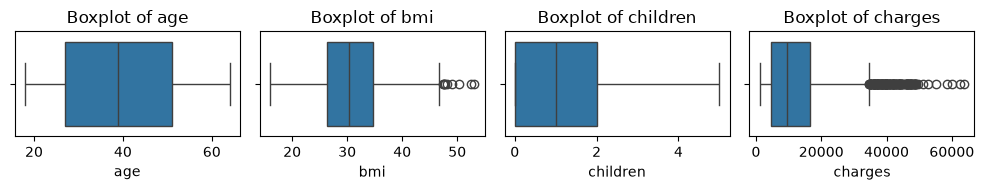

In [33]:
num_cols = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(10,2))
for  i ,col in enumerate(num_cols):
    plt.subplot(1, 4, i+1)
    sns.boxplot(x = df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()    

##  Split into X (features) and Y (target)

In [20]:
x = df.drop("charges" , axis = 1)
y = df["charges"]


In [21]:
print(x.shape)


(1337, 6)


In [22]:
print(y.shape)


(1337,)


In [23]:
x.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [24]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

## Scale numeric columns in X

In [25]:
from preprocessor import scale_numerical_data

x = scale_numerical_data(
    x,
    ["age", "bmi", "children"]
)

x.head()

,age,sex,bmi,children,smoker,region
0,0.021739,female,0.321227,0.0,yes,southwest
1,0.000000,male,0.479150,0.2,no,southeast
2,0.217391,male,0.458434,0.6,no,southeast
3,0.326087,male,0.181464,0.0,no,northwest
4,0.304348,male,0.347592,0.0,no,northwest


## Encode categorical columns in X

In [26]:
from preprocessor import encode_categorical_data

x = encode_categorical_data(
    x,
    ["sex", "smoker", "region"]
)

x.head()

,age,sex_female,sex_male,bmi,children,smoker_yes,smoker_no,region_southwest,region_southeast,region_northwest,region_northeast
0,0.021739,1,0,0.321227,0.0,1,0,1,0,0,0
1,0.000000,0,1,0.479150,0.2,0,1,0,1,0,0
2,0.217391,0,1,0.458434,0.6,0,1,0,1,0,0
3,0.326087,0,1,0.181464,0.0,0,1,0,0,1,0
4,0.304348,0,1,0.347592,0.0,0,1,0,0,1,0


 ## Final Check X and Y Data Types


In [31]:
print("X data types:")
print(x.dtypes)

print("\nY data type:")
print(y.dtype)

print("\nAre all X columns numerical?")
print(x.dtypes.apply(lambda dtype: np.issubdtype(dtype, np.number)).all())

print("\nIs Y numerical?")
print(np.issubdtype(y.dtype, np.number))

X data types:
age                 float64
sex_female            int64
sex_male              int64
bmi                 float64
children            float64
smoker_yes            int64
smoker_no             int64
region_southwest      int64
region_southeast      int64
region_northwest      int64
region_northeast      int64
dtype: object

Y data type:
float64

Are all X columns numerical?
True

Is Y numerical?
True


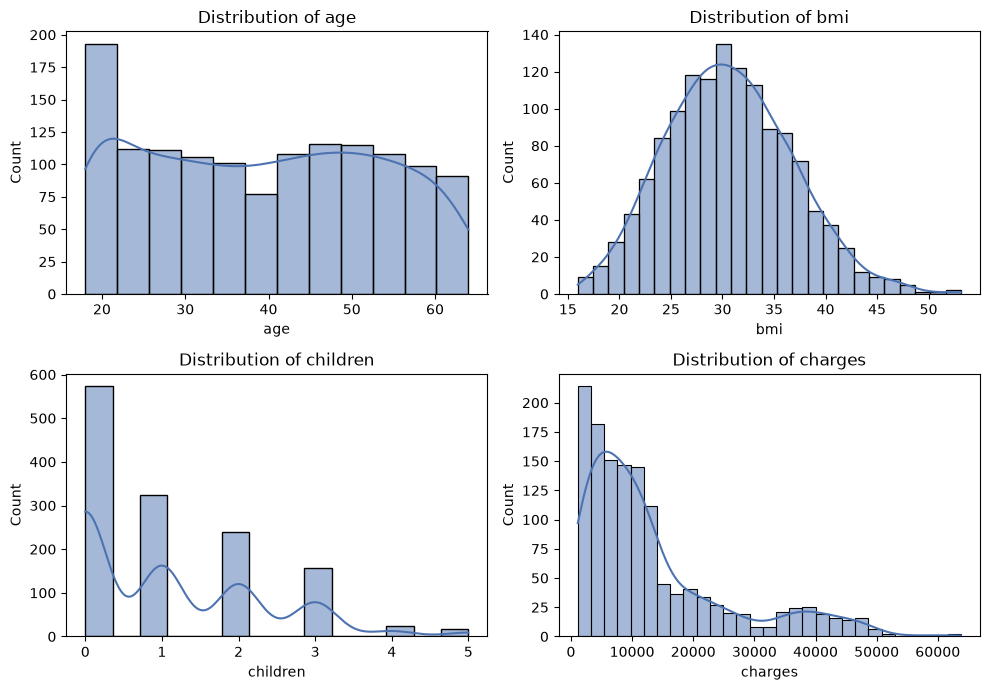

In [34]:

num_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

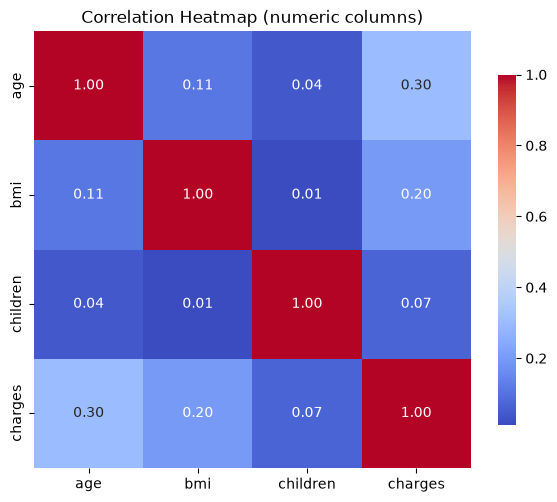

In [35]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Heatmap (numeric columns)')
plt.tight_layout()
plt.show()